
# Notebook 4: nearest neighbour, k-NN, finestre di Parzen e alberi decisionali in 1D

Introduzione alla Data Science

**Docenti**: Luca Calatroni, Lorenzo Rosasco

In questo notebook ci occuperemo di metodi di classificazione binaria usando etichette **$-1$** e **$+1$** confrontando alcuni metodi visti di classificaizone non-lineari visti nel corso.
L'obiettivo è capire **come si costruiscono** i classificatori a partire dagli esempi di training.

Metodi testati:
- nearest neighbour (1-NN),
- $k$-nearest neighbours per pochi valori di $k$,
- finestre di Parzen con pesi decrescenti linearmente,
- un semplice albero decisionale costruito minimizzando il rischio empirico a ogni suddivisione.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=3)


## 1. Dati di training

Generiamo un dataset 1D campionando $x$ da una distribuzione normale. Le etichette assegnate sono $-1$ e $+1$, ma con probabilità di classe $+1$ più alta vicino a $x=0$.


In [2]:

rng = np.random.default_rng(7)

n_train = 40
X_train = np.sort(rng.normal(loc=0.0, scale=1.7, size=n_train))

# Simuliamo il caso in cui la classe +1 è più probabile vicino a zero, mentre la classe -1 più probabile lontano da zero.
p_pos = np.exp(-0.5 * (X_train / 1.1) ** 2)
y_train = np.where(rng.random(n_train) < p_pos, 1, -1)

# Controllo per evitare casi degeneri
if np.all(y_train == 1) or np.all(y_train == -1):
    y_train[0] = -1
    y_train[-1] = 1

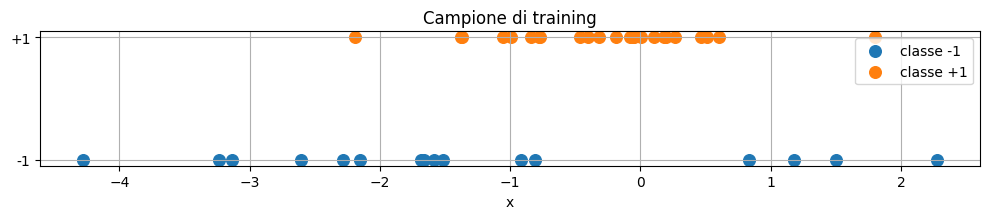

In [3]:

# Visualizzazione del dataset

fig, ax = plt.subplots(figsize=(10, 2.3))
ax.scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=70, label="classe -1")
ax.scatter(X_train[y_train == 1],  np.ones(np.sum(y_train == 1)),  s=70, label="classe +1")
ax.set_yticks([-1, 1])
ax.set_yticklabels(["-1", "+1"])
ax.set_xlabel("x")
ax.set_title("Campione di training")
ax.legend()
plt.tight_layout()
plt.show()



## 2. Nearest neighbour (1-NN)

Dato un punto $x$ su cui siamo interessati a effettuare una predizione (assegnamo inizialmente il valore $y_x = 0$), calcoliamo tutte le distanze

$$
|x-x_i|
$$

e assegniamo a $x$ l'etichetta del punto di training più vicino.


In [4]:

def nearest_neighbour_predict(x, X_train, y_train):
    # TO DO: implementare regola per NN
    distances = np.abs(x - X_train)                             # calcolo la distanza per ogni punto di training
    nearest_index = np.argmin(distances)                        # trovo la distanza minima
    return y_train[nearest_index], distances, nearest_index     # restituisco l'etichetta del vicino più vicino, tutte le distanza e l'indice

x_query = 0.7
pred, distances, idx = nearest_neighbour_predict(x_query, X_train, y_train)

print("punto di query:", x_query)
print("distanze:", distances)
print("indice del punto più vicino:", idx)
print("nearest neighbour:", X_train[idx])
print("etichetta predetta:", pred)


punto di query: 0.7
distanze: [4.978 3.932 3.831 3.301 2.985 2.892 2.855 2.386 2.363 2.282 2.214 2.075
 2.073 1.755 1.692 1.616 1.537 1.512 1.478 1.473 1.166 1.1   1.018 0.89
 0.782 0.755 0.75  0.698 0.598 0.521 0.507 0.434 0.239 0.192 0.093 0.133
 0.482 0.803 1.104 1.578]
indice del punto più vicino: 34
nearest neighbour: 0.6067079138721032
etichetta predetta: 1


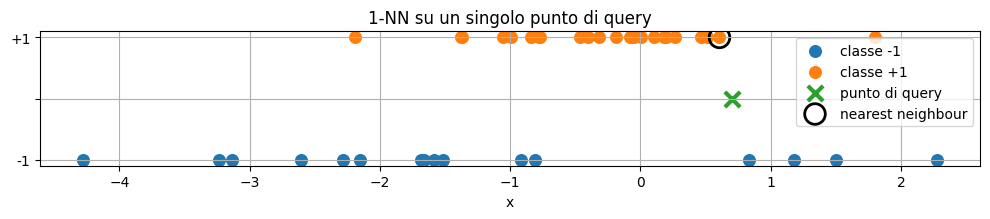

In [5]:

fig, ax = plt.subplots(figsize=(10, 2.3))
ax.scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=70, label="classe -1")
ax.scatter(X_train[y_train == 1],  np.ones(np.sum(y_train == 1)),  s=70, label="classe +1")
ax.scatter([x_query], [0], s=120, marker="x", linewidths=3, label="punto di query")
ax.scatter([X_train[idx]], [y_train[idx]], s=220, facecolors="none", edgecolors="k", linewidths=2,
           label="nearest neighbour")
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["-1", "", "+1"])
ax.set_xlabel("x")
ax.set_title("1-NN su un singolo punto di query")
ax.legend()
plt.tight_layout()
plt.show()



### Domande

1. Qual è la distanza del punto di query dal punto di training in $x=0.8$?
2. Qual è la distanza dal punto in $x=1.6$?
3. Perché il metodo NN assegna al punto di query proprio l'etichetta trovata?


### Risposte

1. La distanza tra i due punti la trovo facendo $ |x_{query} - x_{training}| = |0.7-0.8| = 0.1 $

2. Eseguo lo stesso calcolo fatto nel punto 1: $ |0.7 - 1.6| = 0.9 $

3. Perchè il punto di training più vicino a $ x = 0.7 $ è quello a $ x \approx 0.67 $ (con una distanza di circa $ 0.09 $), che appartiene alla classa $ +1 $. Quindi il metodo 1-NN assegna l'etichetta del vicino più vicino.


## 3. k-NN

Ripetiamo la stessa idea, ma invece di prendere solo il punto più vicino, prendiamo i **$k$ punti più vicini**, con $k$ dispari. La previsione si ottiene con voto di maggioranza.


In [6]:

def knn_predict_one(x, X_train, y_train, k):
    distances = np.abs(X_train - x)
    # TO DO: scrivere l'algoritmo kNN. Hint: procedere prima al riordinamento delle distanze 
    sorted_indices = np.argsort(distances)              
    neighbour_indices = sorted_indices[:k]              # Prendo i k più vicini
    neighbour_labels = y_train[neighbour_indices]

    vote = np.sum(neighbour_labels)                     # Sommo le etichette se prevalgono i +1 il voto è positivo se prevalgono i -1 il segno è negativo
    pred = np.sign(vote)                                

    return pred, distances, neighbour_indices, neighbour_labels

x_query = 0.8

# Test per diversi k

for k in [1, 3, 5]:
    pred, distances, neighbour_indices, neighbour_labels = knn_predict_one(x_query, X_train, y_train, k)
    print(f"k = {k}")
    print(" punti vicini:", X_train[neighbour_indices])
    print(" etichette dei vicini:", neighbour_labels)
    print(" etichetta predetta:", pred)
    print()


k = 1
 punti vicini: [0.833]
 etichette dei vicini: [-1]
 etichetta predetta: -1

k = 3
 punti vicini: [0.833 0.607 0.508]
 etichette dei vicini: [-1  1  1]
 etichetta predetta: 1

k = 5
 punti vicini: [0.833 0.607 0.508 0.461 1.182]
 etichette dei vicini: [-1  1  1  1 -1]
 etichetta predetta: 1



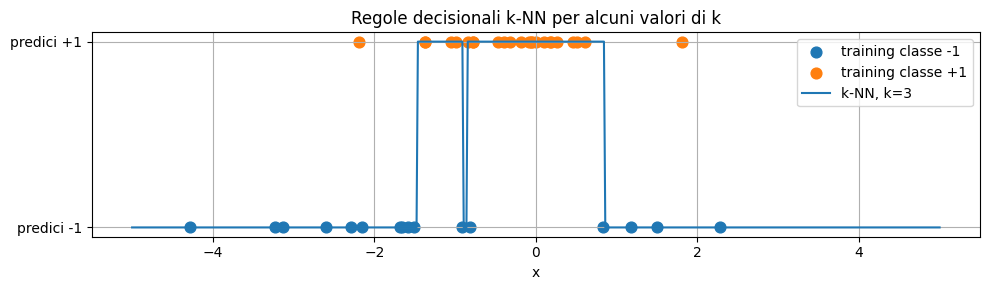

In [ ]:
# Definiamo ora la funzione che, al variare punto x assegna la corrispondente predizione di un algoritmo k-NN

def knn_predict_grid(x_grid, X_train, y_train, k):
    preds = []
    for x in x_grid:
        # TO DO: scrivere la funzione che calcola la predizione al variare di x nell'intervallo
        pred, _, _, _ = knn_predict_one(x, X_train, y_train, k)     # _ = in python è un modo per dire questo valore di ritorno non mi interessa
        preds.append(pred)
    return np.array(preds)

x_grid = np.linspace(-5, 5, 600)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=60, label="training classe -1")
ax.scatter(X_train[y_train == 1],  np.ones(np.sum(y_train == 1)),  s=60, label="training classe +1")

pred_grid = knn_predict_grid(x_grid, X_train, y_train, 3)
ax.plot(x_grid, pred_grid, label=f"k-NN, k=3")

ax.set_yticks([-1, 1])
ax.set_yticklabels(["predici -1", "predici +1"])
ax.set_xlabel("x")
ax.set_title("Regole decisionali k-NN per alcuni valori di k")
ax.legend()
plt.tight_layout()
plt.show()



### Domande
 
1. Ripetere il test con $k=1$ (NN) e $k=5$, come cambia la forma della funzione che effettua la predizione? 
2. In generale, un valore grande di $k$ rende la regola più locale o più regolare? Perché? In caso di dati rumorosi e possibili etichette 'sbagliate', quale regola vi sembra la più robusta?


### Test con $ k=1 $

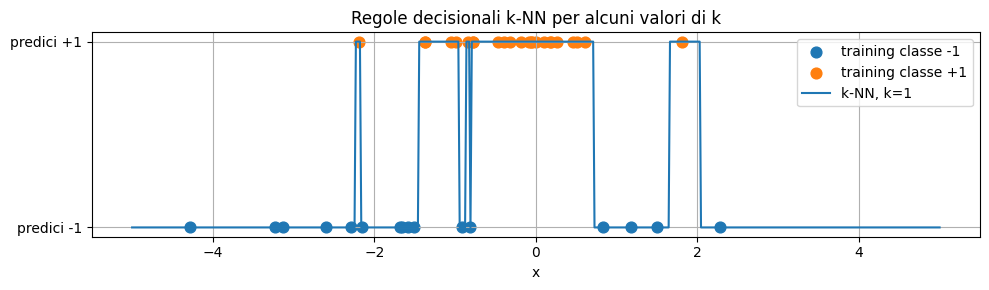

In [9]:
x_grid = np.linspace(-5, 5, 600)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=60, label="training classe -1")
ax.scatter(X_train[y_train == 1],  np.ones(np.sum(y_train == 1)),  s=60, label="training classe +1")

pred_grid = knn_predict_grid(x_grid, X_train, y_train, 1)
ax.plot(x_grid, pred_grid, label=f"k-NN, k=1")

ax.set_yticks([-1, 1])
ax.set_yticklabels(["predici -1", "predici +1"])
ax.set_xlabel("x")
ax.set_title("Regole decisionali k-NN per alcuni valori di k")
ax.legend()
plt.tight_layout()
plt.show()

### Test con $ k=5 $

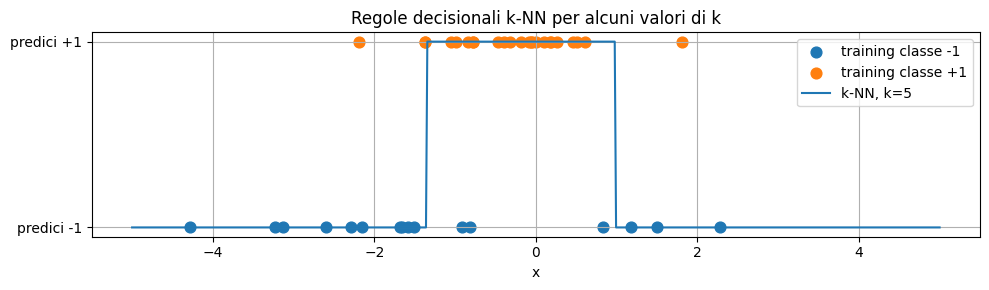

In [10]:
x_grid = np.linspace(-5, 5, 600)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=60, label="training classe -1")
ax.scatter(X_train[y_train == 1],  np.ones(np.sum(y_train == 1)),  s=60, label="training classe +1")

pred_grid = knn_predict_grid(x_grid, X_train, y_train, 5)
ax.plot(x_grid, pred_grid, label=f"k-NN, k=5")

ax.set_yticks([-1, 1])
ax.set_yticklabels(["predici -1", "predici +1"])
ax.set_xlabel("x")
ax.set_title("Regole decisionali k-NN per alcuni valori di k")
ax.legend()
plt.tight_layout()
plt.show()

### Risposte

1. La funzione:
    - Per $ k=1 $: è molto irregolare, a gradini, cambia spesso e bruscamente (non ignora i punti arancioni isolati)
    - Per $ K=3 $: è più regolare, ha pochi gradini
    - Per $ k=5 $: è ancora più regolare rispetto a $ k=3 $, ha un unico gradino di predizioni +1 (ignora i punti arancioni isolati)

2. Per $ k $ grandi la predizione dipende da più vicini quindi la regola è più regolare, quindi un singolo punto non riesce da solo ad influenzare il risultato.  
    Dai grafici posso notare che:
    - con $ k=1 $ la funzione ha molti gradini, quindi anche i punti isolati mi creano una predizione
    - con $ k=5 $ la funzione è molto più "liscia".  
    In caso di dati rumorosi o etichette sbagliate, la regola più robusta è quella con k grande. 
    Un punto mal etichettato influenza direttamente la predizione nella sua zona. 


## 4. Finestre di Parzen con pesi decrescenti linearmente

Per un punto di test $x$, ogni punto di training $x_i$ viene pesato con un peso:

$$
w_i(x)=(1-|x-x_i|/r)_+ = \max\!\left(1-\frac{|x-x_i|}{r},\,0\right).
$$

- il peso è positivo solo quando $|x-x_i|\le r$,
- i punti più vicini a $x$ ricevono peso maggiore,
- i punti con distanza superiore a $r$ ricevono peso nullo.

In [ ]:

def parzen_weights_linear(x, X_train, r):
    # TO DO: scrivere la formula dei pesi
    distances = ...
    weights =...
    return weights, distances

def parzen_predict(x, X_train, y_train, r):
    # TO DO: scrivere la formual del predittore di Parzen
    weights, distances = parzen_weights_linear(x, X_train, r)
    score =...

    pred=np.sign(score)

    return pred, score, weights, distances

x_query = 1.1
r = 1.2

pred, score, weights, distances = parzen_predict(x_query, X_train, y_train, r)

print("distanze:", np.round(distances, 3))
print("pesi:", np.round(weights, 3))
print("score pesato:", round(score, 3))
print("etichetta predetta:", pred)


In [ ]:

# TO DO: rappresentare la predizione al variare di x nell'intervallo

def parzen_predict_grid(x_grid, X_train, y_train, r):
    preds = []
    scores = []
    for x in x_grid:
        # TO DO
        pred, score, _, _ = ...
        preds.append(pred)
        scores.append(score)
    return np.array(preds), np.array(scores)


# Testiamo un punto/raggio 

x_grid = np.linspace(-5, 5, 600)
x_focus = 1.1
r_focus = 1.0

# TO DO: scrivere prima la formula della curva che calcola il peso dato e poi valutarla nel punto x_focus
weight_curve = ...
weights_focus, _ = ...

fig, axs = plt.subplots(
    2, 1, figsize=(10, 5.6), sharex=True, gridspec_kw={"height_ratios": [1.0, 2.0]}
)

# Figure: peso di Parzen centrata su x_focus
axs[0].plot(x_grid, weight_curve, color="tab:orange", label=f"peso w(x), r={r_focus}")
axs[0].scatter(X_train, weights_focus, s=32, color="tab:orange", alpha=0.85, label="peso sui punti train")
axs[0].axvline(x_focus, color="k", linestyle="--", linewidth=1.2, label=f"x_query = {x_focus}")
axs[0].set_ylabel("peso")
axs[0].set_title("Finestra di Parzen: forma del peso")
axs[0].legend(loc="upper right")

# Sotto: regola di decisione in 1D per vari raggi
axs[1].scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=60, label="training classe -1")
axs[1].scatter(X_train[y_train == 1], np.ones(np.sum(y_train == 1)), s=60, label="training classe +1")

pred_grid, _ = parzen_predict_grid(x_grid, X_train, y_train, 0.6)
axs[1].plot(x_grid, pred_grid, label=f"Parzen, r=0.6")

axs[1].set_yticks([-1, 1])
axs[1].set_yticklabels(["predici -1", "predici +1"])
axs[1].set_xlabel("x")
axs[1].set_title("Regola di Parzen per alcuni valori del raggio")
axs[1].legend(loc="upper right")

plt.tight_layout()
plt.show()



### Domande

1. Quali punti contribuiscono davvero al voto quando $r=1.2$ e $x=1.1$?
2. Quale punto riceve il peso più grande?
3. Che cosa succede se diminuiamo molto $r$?
4. Che differenza concettuale c'è fra k-NN e Parzen?



## 5. Partizioni e alberi decisionali in 1D

Partiamo da una partizione assegnata:
1. consideriamo soglie candidate fra punti consecutivi del training;
2. scegliamo la soglia che minimizza l'errore sul training;
3. a sinistra e destra assegniamo la classe di maggioranza.

In [ ]:

def majority_label(y):
    return np.sign(y)

def empirical_risk_of_split(X, y, threshold):
    left = X <= threshold
    right = ~left
    if not left.any() or not right.any():
        return np.inf, None, None

    y_left, y_right = y[left], y[right]

    # TO DO: ricordatevi come sono definiti i coefficienti ottimi dell'ERM e scriveteli per le due regioni trovate
    # c_A ottimi per loss quadratica: media delle etichette nel blocco A


    c_left =...
    c_right = ...

    # TO DO: scrivere il valore dell'ERM  con loss quadratica dopo lo splitting: sum_A sum_{x_i in A} (c_A - y_i)^2
    risk = np.sum((...) ** 2) + np.sum((...) ** 2)

    # TO DO definire la regola di classificazione
    left_label = ...
    right_label = ...

    return risk, left_label, right_label



def best_threshold(X, y):
    order = np.argsort(X)
    Xs, ys = X[order], y[order]

    # TO DO: definire come threshold candidati i punti medi tra i campioni
    candidate_thresholds = ...

    # Inizializzazione
    best_thr, best_risk = None, np.inf
    best_left_label, best_right_label = None, None

    for thr in candidate_thresholds:
        risk, left_label, right_label = empirical_risk_of_split(Xs, ys, thr)
        # TO DO: confrontare il valore appena calcolato con gli altri per trovare il migliore
        if ...:
            best_thr, best_risk = ...
            best_left_label, best_right_label = ...

    return best_thr, best_risk, best_left_label, best_right_label, candidate_thresholds


In [ ]:

thr, risk, left_label, right_label, candidate_thresholds = best_threshold(X_train, y_train)

print("soglia migliore:", round(thr, 3))
print("rischio empirico:", round(risk, 3))


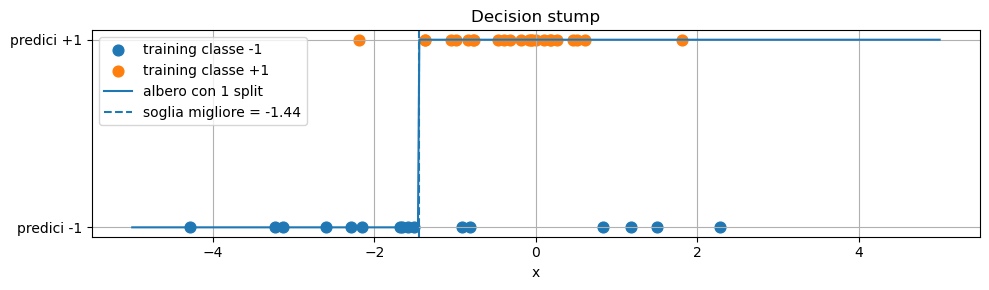

In [77]:
def class_predict(x, threshold, left_label, right_label):
    if x <= threshold:
        return left_label
    return right_label

def stump_predict_grid(x_grid, threshold, left_label, right_label):
    return np.array([class_predict(x, threshold, left_label, right_label) for x in x_grid])

x_grid = np.linspace(-5, 5, 600)
stump_pred = stump_predict_grid(x_grid, thr, left_label, right_label)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(X_train[y_train == -1], -np.ones(np.sum(y_train == -1)), s=60, label="training classe -1")
ax.scatter(X_train[y_train == 1],  np.ones(np.sum(y_train == 1)),  s=60, label="training classe +1")
ax.plot(x_grid, stump_pred, label="albero con 1 split")
ax.axvline(thr, linestyle="--", label=f"soglia migliore = {thr:.2f}")
ax.set_yticks([-1, 1])
ax.set_yticklabels(["predici -1", "predici +1"])
ax.set_xlabel("x")
ax.set_title("Decision stump")
ax.legend()
plt.tight_layout()
plt.show()



### Domande

1. Perché le soglie candidate sono prese fra due punti consecutivi?
2. Che cosa significa qui “rischio empirico”?
3. Dopo la divisione, quale etichetta viene assegnata al lato sinistro?
4. Prova a scegliere a mano una soglia diversa: pensi che l'errore aumenti o diminuisca?
5. Discutere la costruzione (e, se si vuole, proporre l'implementazione) di un albero decisionale che, a partire da questa partizione, ne costruisca un'altra raffinando ulteriormente l'intervallo di destra per migliorare la predizione.
